In [2]:
# Install the Earth Engine Python library
# !pip install earthengine-api
# !pip install folium

import os
import ee
# import folium
import pandas as pd
import matplotlib.pyplot as plt

# Authenticate. This should only be necessary once. I ran the script in debug mode first, and authentication involved a visit of an external web site, generation of a token, and copy/paste of this in VS Code.
# ee.Authenticate()

# Specify data sources
collections = {
    'COPERNICUS/S5P/NRTI/L3_AER_AI': {
        'start': '2018-07-10',
        'end': '2024-05-31', 
        'variables': ['absorbing_aerosol_index', 
                      ],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S5P_NRTI_L3_AER_AI'
    },
    'COPERNICUS/S5P/OFFL/L3_AER_AI': {
        'start': '2018-07-10',
        'end': '2024-05-31', 
        'variables': ['absorbing_aerosol_index', 
                      ],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S5P_OFFL_L3_AER_AI'
    },
    'COPERNICUS/S5P/NRTI/L3_CO': {
        'start': '2018-11-22',
        'end': '',
        'variables': ['CO_column_number_density',
                      'H2O_column_number_density',
                      'cloud_height',
                      'sensor_altitude',
                      'sensor_azimuth_angle',
                      'sensor_zenith_angle',
                      'solar_azimuth_angle',
                      'solar_zenith_angle'],
        'description': '',
    }, 
    'COPERNICUS/S5P/OFFL/L3_CO': {
        'start': '2018-07-10',
        'end': '2024-05-31',
        'variables': ['CO_column_number_density',
                      'H2O_column_number_density',
                      'cloud_height',
                    #   'sensor_altitude',
                    #   'sensor_azimuth_angle',
                    #   'sensor_zenith_angle',
                    #   'solar_azimuth_angle',
                    #   'solar_zenith_angle',
                    ],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S5P_OFFL_L3_CO',
    },
    'COPERNICUS/S5P/NRTI/L3_NO2': {
        'start': '2018-07-10',
        'end': '2024-05-31',
        'variables': ['NO2_column_number_density',
                      'tropospheric_NO2_column_number_density',
                      'stratospheric_NO2_column_number_density',
                      'NO2_slant_column_number_density',
                      'tropopause_pressure',
                      'absorbing_aerosol_index',
                      'cloud_fraction',
                    #   'sensor_altitude',
                    #   'sensor_azimuth_angle',
                    #   'sensor_zenith_angle',
                    #   'solar_azimuth_angle',
                    #   'solar_zenith_angle',
                      ],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S5P_NRTI_L3_NO2',
    }, 
    'COPERNICUS/S5P/OFFL/L3_NO2': {
        'start': '2018-07-10',
        'end': '2024-05-31',
        'variables': ['NO2_column_number_density',
                      'tropospheric_NO2_column_number_density',
                      'stratospheric_NO2_column_number_density',
                      'NO2_slant_column_number_density',
                      'tropopause_pressure',
                      'absorbing_aerosol_index',
                      'cloud_fraction',
                    #   'sensor_altitude',
                    #   'sensor_azimuth_angle',
                    #   'sensor_zenith_angle',
                    #   'solar_azimuth_angle',
                    #   'solar_zenith_angle',
                      ],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S5P_OFFL_L3_NO2',
    }, 
    'COPERNICUS/S5P/NRTI/L3_O3': {
        'start': '2018-07-10',
        'end': '2024-05-31',
        'variables': ['O3_column_number_density',
                      'O3_effective_temperature',
                      'cloud_fraction',
                    #   'sensor_azimuth_angle',
                    #   'sensor_zenith_angle',
                    #   'solar_azimuth_angle',
                    #   'solar_zenith_angle',
                      ],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S5P_NRTI_L3_O3',
    }, 
    'COPERNICUS/S5P/OFFL/L3_O3': {
        'start': '2018-09-08',
        'end': '2024-05-31',
        'variables': ['O3_column_number_density',
                      'O3_effective_temperature',
                      'cloud_fraction',
                    #   'sensor_azimuth_angle',
                    #   'sensor_zenith_angle',
                    #   'solar_azimuth_angle',
                    #   'solar_zenith_angle',
                      ],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S5P_OFFL_L3_O3',
    }, 
    'COPERNICUS/S5P/OFFL/L3_O3_TCL': {
        'start': '2018-04-30',
        'end': '2024-05-31',
        'variables': ['ozone_tropospheric_mixing_ratio',
                      'ozone_tropospheric_mixing_ratio_precision',
                      'ozone_tropospheric_vertical_column','ozone_tropospheric_vertical_column_precision',
                       'qa_value'],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S5P_OFFL_L3_O3',
    }, 
    'COPERNICUS/S5P/OFFL/L3_CH4': {
        'start': '2019-02-08',
        'end': '2024-05-31',
        'variables': ['CH4_column_volume_mixing_ratio_dry_air',
                      'aerosol_height',
                      'aerosol_optical_depth',
                    #   'sensor_azimuth_angle',
                    #   'sensor_zenith_angle',
                    #   'solar_azimuth_angle',
                    #   'solar_zenith_angle',
                      'CH4_column_volume_mixing_ratio_dry_air_bias_corrected',
                      'CH4_column_volume_mixing_ratio_dry_air_uncertainty'],
        'description': '',
    }, 
    'MODIS/061/MCD19A2_GRANULES': {
        # 'start': '1999-01-01',
        'start': '2019-01-01',
        'end': '2024-05-31',
        'variables': ['Optical_Depth_047', 
                      'Optical_Depth_055', 
                      'AOD_Uncertainty', 
                      'Column_WV', 
                      'AOD_QA', 
                      'Injection_Height',  
                    #   'cosSZA',
                    #   'cosVZA',
                    #   'RelAZ',
                    #   'Scattering_Angle',
                    #   'Glint_Angle',
                      'FineModeFraction',
                      'AngstromExp_470-780',    # only over the ocean?
                      ],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MCD19A2_GRANULES'
    },
    'MODIS/061/MCD64A1': {
        'start': '1999-01-01',
        'end': '2024-05-31',
        'variables': ['BurnDate', 
                      'Uncertainty', 
                      'QA', 
                      'FirstDay', 
                      'LastDay',],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MCD64A1'
    },
    'ESA/CCI/FireCCI/5_1': {
        'start': '2001-01-01',
        'end': '2020-12-01',
        'variables': ['BurnDate', 
                      'ConfidenceLevel', 
                      'LandCover', 
                      'ObservedFlag'],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/ESA_CCI_FireCCI_5_1'
    },
    'FIRMS': {
        'start': '2001-01-01',
        'end': '2020-12-01',
        'variables': ['T21', 'confidence', 'line_number'],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/FIRMS',
    },
    'JAXA/GCOM-C/L3/LAND/LST/V3': {
        'start': '2021-11-29',
        'end': '2024-06-05',
        'variables': ['LST_AVE', 'LST_QA_flag'],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/JAXA_GCOM-C_L3_LAND_LST_V3',
    },
    'JAXA/GPM_L3/GSMaP/v8/operational': {
        'start': '1998-01-01',
        'end': '2024-06-05',
        'variables': [],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/JAXA_GPM_L3_GSMaP_v8_operational',
    },
    # 'JRC/GWIS/GlobFire/v2/FinalPerimeters': {
    #     'start': '2001-01-01',
    #     'end': '2021-01-01',
    #     'variables': [],
    #     'description': 'https://developers.google.com/earth-engine/datasets/catalog/JRC_GWIS_GlobFire_v2_FinalPerimeters',
    # },
    'MODIS/061/MOD08_M3': {
        'start': '2000-02-01',
        'end': '2024-04-01',
        'variables': [
            # 'Solar_Zenith_Mean_Mean',
            # 'Solar_Zenith_Std_Deviation_Mean',
            # 'Solar_Azimuth_Mean_Mean',
            # 'Solar_Azimuth_Std_Deviation_Mean',
            # 'Sensor_Zenith_Mean_Mean',
            # 'Sensor_Zenith_Std_Deviation_Mean',
            # 'Sensor_Azimuth_Mean_Mean',
            # 'Sensor_Azimuth_Std_Deviation_Mean',
            'Aerosol_Scattering_Angle_Mean_Mean',
            'Aerosol_Scattering_Angle_Std_Deviation_Mean',
            # 'Aerosol_Avg_Cloud_Distance_Land_Ocean_Mean_Mean',
            # 'Aerosol_Avg_Cloud_Distance_Land_Ocean_Std_Deviation_Mean',
            # 'Aerosol_Optical_Depth_Land_Ocean_Mean_Mean',
            # 'Aerosol_Optical_Depth_Land_Ocean_Std_Deviation_Mean',
            # 'Aerosol_Optical_Depth_Land_Mean_Mean_470',
            # 'Aerosol_Optical_Depth_Land_Mean_Mean_550',
            # 'Aerosol_Optical_Depth_Land_Mean_Mean_660',
            # 'Aerosol_Optical_Depth_Land_Std_Deviation_Mean_470',
            # 'Aerosol_Optical_Depth_Land_Std_Deviation_Mean_550',
            # 'Aerosol_Optical_Depth_Land_Std_Deviation_Mean_660',
            # 'Aerosol_Optical_Depth_Land_QA_Mean_Mean_470',
            # 'Aerosol_Optical_Depth_Land_QA_Mean_Mean_550',
            # 'Aerosol_Optical_Depth_Land_QA_Mean_Mean_660',
            # 'Aerosol_Optical_Depth_Land_QA_Std_Deviation_Mean_470',
            # 'Aerosol_Optical_Depth_Land_QA_Std_Deviation_Mean_550',
            # 'Aerosol_Optical_Depth_Land_QA_Std_Deviation_Mean_660',
            # 'Aerosol_Number_Pixels_Used_Land_Mean_Mean_470',
            # 'Aerosol_Number_Pixels_Used_Land_Mean_Mean_550',
            # 'Aerosol_Number_Pixels_Used_Land_Mean_Mean_660',
            # 'Aerosol_Number_Pixels_Used_Land_Mean_Mean_870',
            # 'Aerosol_Number_Pixels_Used_Land_Mean_Mean_1240',
            # 'Aerosol_Number_Pixels_Used_Land_Mean_Mean_1640',
            # 'Aerosol_Number_Pixels_Used_Land_Mean_Mean_2130',
            # 'Aerosol_Number_Pixels_Used_Land_Mean_Mean_412',
            # 'Aerosol_Number_Pixels_Used_Land_Mean_Mean_443',
            # 'Aerosol_Number_Pixels_Used_Land_Mean_Mean_745',
            # 'Aerosol_Number_Pixels_Used_Land_Std_Deviation_Mean_470',
            # 'Aerosol_Number_Pixels_Used_Land_Std_Deviation_Mean_550',
            # 'Aerosol_Number_Pixels_Used_Land_Std_Deviation_Mean_660',
            # 'Aerosol_Number_Pixels_Used_Land_Std_Deviation_Mean_870',
            # 'Aerosol_Number_Pixels_Used_Land_Std_Deviation_Mean_1240',
            # 'Aerosol_Number_Pixels_Used_Land_Std_Deviation_Mean_1640',
            # 'Aerosol_Number_Pixels_Used_Land_Std_Deviation_Mean_2130',
            # 'Aerosol_Number_Pixels_Used_Land_Std_Deviation_Mean_412',
            # 'Aerosol_Number_Pixels_Used_Land_Std_Deviation_Mean_443',
            # 'Aerosol_Number_Pixels_Used_Land_Std_Deviation_Mean_745',
            # 'Aerosol_Number_Pixels_Used_Land_QA_Mean_Mean_470',
            # 'Aerosol_Number_Pixels_Used_Land_QA_Mean_Mean_550',
            # 'Aerosol_Number_Pixels_Used_Land_QA_Mean_Mean_660',
            # 'Aerosol_Number_Pixels_Used_Land_QA_Mean_Mean_870',
            # 'Aerosol_Number_Pixels_Used_Land_QA_Mean_Mean_1240',
            # 'Aerosol_Number_Pixels_Used_Land_QA_Mean_Mean_1640',
            # 'Aerosol_Number_Pixels_Used_Land_QA_Mean_Mean_2130',
            # 'Aerosol_Number_Pixels_Used_Land_QA_Mean_Mean_412',
            # 'Aerosol_Number_Pixels_Used_Land_QA_Mean_Mean_443',
            # 'Aerosol_Number_Pixels_Used_Land_QA_Mean_Mean_745',
            # 'Aerosol_Number_Pixels_Used_Land_QA_Std_Deviation_Mean_470',
            # 'Aerosol_Number_Pixels_Used_Land_QA_Std_Deviation_Mean_550',
            # 'Aerosol_Number_Pixels_Used_Land_QA_Std_Deviation_Mean_660',
            # 'Aerosol_Number_Pixels_Used_Land_QA_Std_Deviation_Mean_870',
            # 'Aerosol_Number_Pixels_Used_Land_QA_Std_Deviation_Mean_1240',
            # 'Aerosol_Number_Pixels_Used_Land_QA_Std_Deviation_Mean_1640',
            # 'Aerosol_Number_Pixels_Used_Land_QA_Std_Deviation_Mean_2130',
            # 'Aerosol_Number_Pixels_Used_Land_QA_Std_Deviation_Mean_412',
            # 'Aerosol_Number_Pixels_Used_Land_QA_Std_Deviation_Mean_443',
            # 'Aerosol_Number_Pixels_Used_Land_QA_Std_Deviation_Mean_745',
            # 'Deep_Blue_Aerosol_Optical_Depth_Land_Mean_Mean_412',
            # 'Deep_Blue_Aerosol_Optical_Depth_Land_Mean_Mean_470',
            # 'Deep_Blue_Aerosol_Optical_Depth_Land_Mean_Mean_660',
            # 'Deep_Blue_Aerosol_Optical_Depth_Land_Std_Deviation_Mean_412',
            # 'Deep_Blue_Aerosol_Optical_Depth_Land_Std_Deviation_Mean_470',
            # 'Deep_Blue_Aerosol_Optical_Depth_Land_Std_Deviation_Mean_660',
            # 'Deep_Blue_Aerosol_Optical_Depth_550_Land_Mean_Mean',
            # 'Deep_Blue_Aerosol_Optical_Depth_550_Land_Std_Deviation_Mean',
            # 'Deep_Blue_Angstrom_Exponent_Land_Mean_Mean',
            # 'Deep_Blue_Angstrom_Exponent_Land_Std_Deviation_Mean',
            # 'Deep_Blue_Single_Scattering_Albedo_Land_Mean_Mean_412',
            # 'Deep_Blue_Single_Scattering_Albedo_Land_Mean_Mean_470',
            # 'Deep_Blue_Single_Scattering_Albedo_Land_Mean_Mean_660',
            # 'Deep_Blue_Single_Scattering_Albedo_Land_Std_Deviation_Mean_412',
            # 'Deep_Blue_Single_Scattering_Albedo_Land_Std_Deviation_Mean_470',
            # 'Deep_Blue_Single_Scattering_Albedo_Land_Std_Deviation_Mean_660',
            # 'Deep_Blue_Number_Pixels_Used_550_Land_Mean_Mean',
            # 'Deep_Blue_Number_Pixels_Used_550_Land_Std_Deviation_Mean',
            # 'AOD_550_Dark_Target_Deep_Blue_Combined_Mean_Mean',
            # 'AOD_550_Dark_Target_Deep_Blue_Combined_Std_Deviation_Mean',
            # 'Aerosol_Optical_Depth_Average_Ocean_Mean_Mean_470',
            # 'Aerosol_Optical_Depth_Average_Ocean_Mean_Mean_550',
            # 'Aerosol_Optical_Depth_Average_Ocean_Mean_Mean_660',
            # 'Aerosol_Optical_Depth_Average_Ocean_Mean_Mean_870',
            # 'Aerosol_Optical_Depth_Average_Ocean_Mean_Mean_1240',
            # 'Aerosol_Optical_Depth_Average_Ocean_Mean_Mean_1640',
            # 'Aerosol_Optical_Depth_Average_Ocean_Mean_Mean_2130',
            # 'Aerosol_Optical_Depth_Average_Ocean_Std_Deviation_Mean_470',
            # 'Aerosol_Optical_Depth_Average_Ocean_Std_Deviation_Mean_550',
            # 'Aerosol_Optical_Depth_Average_Ocean_Std_Deviation_Mean_660',
            # 'Aerosol_Optical_Depth_Average_Ocean_Std_Deviation_Mean_870',
            # 'Aerosol_Optical_Depth_Average_Ocean_Std_Deviation_Mean_1240',
            # 'Aerosol_Optical_Depth_Average_Ocean_Std_Deviation_Mean_1640',
            # 'Aerosol_Optical_Depth_Average_Ocean_Std_Deviation_Mean_2130',
            # 'Aerosol_Optical_Depth_Average_Ocean_QA_Mean_Mean_470',
            # 'Aerosol_Optical_Depth_Average_Ocean_QA_Mean_Mean_550',
            # 'Aerosol_Optical_Depth_Average_Ocean_QA_Mean_Mean_660',
            # 'Aerosol_Optical_Depth_Average_Ocean_QA_Mean_Mean_870',
            # 'Aerosol_Optical_Depth_Average_Ocean_QA_Mean_Mean_1240',
            # 'Aerosol_Optical_Depth_Average_Ocean_QA_Mean_Mean_1640',
            # 'Aerosol_Optical_Depth_Average_Ocean_QA_Mean_Mean_2130',
            # 'Aerosol_Optical_Depth_Average_Ocean_QA_Std_Deviation_Mean_470',
            # 'Aerosol_Optical_Depth_Average_Ocean_QA_Std_Deviation_Mean_550',
            # 'Aerosol_Optical_Depth_Average_Ocean_QA_Std_Deviation_Mean_660',
            # 'Aerosol_Optical_Depth_Average_Ocean_QA_Std_Deviation_Mean_870',
            # 'Aerosol_Optical_Depth_Average_Ocean_QA_Std_Deviation_Mean_1240',
            # 'Aerosol_Optical_Depth_Average_Ocean_QA_Std_Deviation_Mean_1640',
            # 'Aerosol_Optical_Depth_Average_Ocean_QA_Std_Deviation_Mean_2130',
            # 'Aerosol_Optical_Depth_Small_Ocean_Mean_Mean_470',
            # 'Aerosol_Optical_Depth_Small_Ocean_Mean_Mean_550',
            # 'Aerosol_Optical_Depth_Small_Ocean_Mean_Mean_660',
            # 'Aerosol_Optical_Depth_Small_Ocean_Mean_Mean_870',
            # 'Aerosol_Optical_Depth_Small_Ocean_Mean_Mean_1240',
            # 'Aerosol_Optical_Depth_Small_Ocean_Mean_Mean_1640',
            # 'Aerosol_Optical_Depth_Small_Ocean_Mean_Mean_2130',
            # 'Aerosol_Optical_Depth_Small_Ocean_Std_Deviation_Mean_470',
            # 'Aerosol_Optical_Depth_Small_Ocean_Std_Deviation_Mean_550',
            # 'Aerosol_Optical_Depth_Small_Ocean_Std_Deviation_Mean_660',
            # 'Aerosol_Optical_Depth_Small_Ocean_Std_Deviation_Mean_870',
            # 'Aerosol_Optical_Depth_Small_Ocean_Std_Deviation_Mean_1240',
            # 'Aerosol_Optical_Depth_Small_Ocean_Std_Deviation_Mean_1640',
            # 'Aerosol_Optical_Depth_Small_Ocean_Std_Deviation_Mean_2130',
            # 'Aerosol_Optical_Depth_Small_Ocean_QA_Mean_Mean_470',
            # 'Aerosol_Optical_Depth_Small_Ocean_QA_Mean_Mean_550',
            # 'Aerosol_Optical_Depth_Small_Ocean_QA_Mean_Mean_660',
            # 'Aerosol_Optical_Depth_Small_Ocean_QA_Mean_Mean_870',
            # 'Aerosol_Optical_Depth_Small_Ocean_QA_Mean_Mean_1240',
            # 'Aerosol_Optical_Depth_Small_Ocean_QA_Mean_Mean_1640',
            # 'Aerosol_Optical_Depth_Small_Ocean_QA_Mean_Mean_2130',
            # 'Aerosol_Optical_Depth_Small_Ocean_QA_Std_Deviation_Mean_470',
            # 'Aerosol_Optical_Depth_Small_Ocean_QA_Std_Deviation_Mean_550',
            # 'Aerosol_Optical_Depth_Small_Ocean_QA_Std_Deviation_Mean_660',
            # 'Aerosol_Optical_Depth_Small_Ocean_QA_Std_Deviation_Mean_870',
            # 'Aerosol_Optical_Depth_Small_Ocean_QA_Std_Deviation_Mean_1240',
            # 'Aerosol_Optical_Depth_Small_Ocean_QA_Std_Deviation_Mean_1640',
            # 'Aerosol_Optical_Depth_Small_Ocean_QA_Std_Deviation_Mean_2130',
            # 'Aerosol_PSML003_Ocean_Mean_Mean',
            # 'Aerosol_PSML003_Ocean_Std_Deviation_Mean',
            # 'Aerosol_PSML003_Ocean_QA_Mean_Mean',
            # 'Aerosol_PSML003_Ocean_QA_Std_Deviation_Mean',
            # 'Aerosol_Optical_Depth_by_models_ocean_Mean_Mean_1',
            # 'Aerosol_Optical_Depth_by_models_ocean_Mean_Mean_2',
            # 'Aerosol_Optical_Depth_by_models_ocean_Mean_Mean_3',
            # 'Aerosol_Optical_Depth_by_models_ocean_Mean_Mean_4',
            # 'Aerosol_Optical_Depth_by_models_ocean_Mean_Mean_5',
            # 'Aerosol_Optical_Depth_by_models_ocean_Mean_Mean_6',
            # 'Aerosol_Optical_Depth_by_models_ocean_Mean_Mean_7',
            # 'Aerosol_Optical_Depth_by_models_ocean_Mean_Mean_8',
            # 'Aerosol_Optical_Depth_by_models_ocean_Mean_Mean_9',
            # 'Aerosol_Optical_Depth_by_models_ocean_Std_Deviation_Mean_1',
            # 'Aerosol_Optical_Depth_by_models_ocean_Std_Deviation_Mean_2',
            # 'Aerosol_Optical_Depth_by_models_ocean_Std_Deviation_Mean_3',
            # 'Aerosol_Optical_Depth_by_models_ocean_Std_Deviation_Mean_4',
            # 'Aerosol_Optical_Depth_by_models_ocean_Std_Deviation_Mean_5',
            # 'Aerosol_Optical_Depth_by_models_ocean_Std_Deviation_Mean_6',
            # 'Aerosol_Optical_Depth_by_models_ocean_Std_Deviation_Mean_7',
            # 'Aerosol_Optical_Depth_by_models_ocean_Std_Deviation_Mean_8',
            # 'Aerosol_Optical_Depth_by_models_ocean_Std_Deviation_Mean_9',
            # 'Aerosol_Optical_Depth_by_models_ocean_QA_Mean_Mean_1',
            # 'Aerosol_Optical_Depth_by_models_ocean_QA_Mean_Mean_2',
            # 'Aerosol_Optical_Depth_by_models_ocean_QA_Mean_Mean_3',
            # 'Aerosol_Optical_Depth_by_models_ocean_QA_Mean_Mean_4',
            # 'Aerosol_Optical_Depth_by_models_ocean_QA_Mean_Mean_5',
            # 'Aerosol_Optical_Depth_by_models_ocean_QA_Mean_Mean_6',
            # 'Aerosol_Optical_Depth_by_models_ocean_QA_Mean_Mean_7',
            # 'Aerosol_Optical_Depth_by_models_ocean_QA_Mean_Mean_8',
            # 'Aerosol_Optical_Depth_by_models_ocean_QA_Mean_Mean_9',
            # 'Aerosol_Optical_Depth_by_models_ocean_QA_Std_Deviation_Mean_1',
            # 'Aerosol_Optical_Depth_by_models_ocean_QA_Std_Deviation_Mean_2',
            # 'Aerosol_Optical_Depth_by_models_ocean_QA_Std_Deviation_Mean_3',
            # 'Aerosol_Optical_Depth_by_models_ocean_QA_Std_Deviation_Mean_4',
            # 'Aerosol_Optical_Depth_by_models_ocean_QA_Std_Deviation_Mean_5',
            # 'Aerosol_Optical_Depth_by_models_ocean_QA_Std_Deviation_Mean_6',
            # 'Aerosol_Optical_Depth_by_models_ocean_QA_Std_Deviation_Mean_7',
            # 'Aerosol_Optical_Depth_by_models_ocean_QA_Std_Deviation_Mean_8',
            # 'Aerosol_Optical_Depth_by_models_ocean_QA_Std_Deviation_Mean_9',
            # 'Aerosol_Number_Pixels_Used_Ocean_Mean_Mean_470',
            # 'Aerosol_Number_Pixels_Used_Ocean_Mean_Mean_550',
            # 'Aerosol_Number_Pixels_Used_Ocean_Mean_Mean_660',
            # 'Aerosol_Number_Pixels_Used_Ocean_Mean_Mean_870',
            # 'Aerosol_Number_Pixels_Used_Ocean_Mean_Mean_1240',
            # 'Aerosol_Number_Pixels_Used_Ocean_Mean_Mean_1640',
            # 'Aerosol_Number_Pixels_Used_Ocean_Mean_Mean_2130',
            # 'Aerosol_Number_Pixels_Used_Ocean_Mean_Mean_412',
            # 'Aerosol_Number_Pixels_Used_Ocean_Mean_Mean_443',
            # 'Aerosol_Number_Pixels_Used_Ocean_Mean_Mean_745',
            # 'Aerosol_Number_Pixels_Used_Ocean_Std_Deviation_Mean_470',
            # 'Aerosol_Number_Pixels_Used_Ocean_Std_Deviation_Mean_550',
            # 'Aerosol_Number_Pixels_Used_Ocean_Std_Deviation_Mean_660',
            # 'Aerosol_Number_Pixels_Used_Ocean_Std_Deviation_Mean_870',
            # 'Aerosol_Number_Pixels_Used_Ocean_Std_Deviation_Mean_1240',
            # 'Aerosol_Number_Pixels_Used_Ocean_Std_Deviation_Mean_1640',
            # 'Aerosol_Number_Pixels_Used_Ocean_Std_Deviation_Mean_2130',
            # 'Aerosol_Number_Pixels_Used_Ocean_Std_Deviation_Mean_412',
            # 'Aerosol_Number_Pixels_Used_Ocean_Std_Deviation_Mean_443',
            # 'Aerosol_Number_Pixels_Used_Ocean_Std_Deviation_Mean_745',
            # 'Aerosol_Number_Pixels_Used_Ocean_QA_Mean_Mean_470',
            # 'Aerosol_Number_Pixels_Used_Ocean_QA_Mean_Mean_550',
            # 'Aerosol_Number_Pixels_Used_Ocean_QA_Mean_Mean_660',
            # 'Aerosol_Number_Pixels_Used_Ocean_QA_Mean_Mean_870',
            # 'Aerosol_Number_Pixels_Used_Ocean_QA_Mean_Mean_1240',
            # 'Aerosol_Number_Pixels_Used_Ocean_QA_Mean_Mean_1640',
            # 'Aerosol_Number_Pixels_Used_Ocean_QA_Mean_Mean_2130',
            # 'Aerosol_Number_Pixels_Used_Ocean_QA_Mean_Mean_412',
            # 'Aerosol_Number_Pixels_Used_Ocean_QA_Mean_Mean_443',
            # 'Aerosol_Number_Pixels_Used_Ocean_QA_Mean_Mean_745',
            # 'Aerosol_Number_Pixels_Used_Ocean_QA_Std_Deviation_Mean_470',
            # 'Aerosol_Number_Pixels_Used_Ocean_QA_Std_Deviation_Mean_550',
            # 'Aerosol_Number_Pixels_Used_Ocean_QA_Std_Deviation_Mean_660',
            # 'Aerosol_Number_Pixels_Used_Ocean_QA_Std_Deviation_Mean_870',
            # 'Aerosol_Number_Pixels_Used_Ocean_QA_Std_Deviation_Mean_1240',
            # 'Aerosol_Number_Pixels_Used_Ocean_QA_Std_Deviation_Mean_1640',
            # 'Aerosol_Number_Pixels_Used_Ocean_QA_Std_Deviation_Mean_2130',
            # 'Aerosol_Number_Pixels_Used_Ocean_QA_Std_Deviation_Mean_412',
            # 'Aerosol_Number_Pixels_Used_Ocean_QA_Std_Deviation_Mean_443',
            # 'Aerosol_Number_Pixels_Used_Ocean_QA_Std_Deviation_Mean_745',
            # 'Water_Vapor_Near_Infrared_Clear_Mean_Mean',
            # 'Water_Vapor_Near_Infrared_Clear_Std_Deviation_Mean',
            # 'Water_Vapor_Near_Infrared_Cloud_Mean_Mean',
            # 'Water_Vapor_Near_Infrared_Cloud_Std_Deviation_Mean',
            # 'Cirrus_Reflectance_Mean_Mean',
            # 'Cirrus_Reflectance_Std_Deviation_Mean',
            # 'Cirrus_Fraction_SWIR_FMean',
            # 'Cirrus_Fraction_SWIR_FStd',
            # 'Cloud_Top_Temperature_Mean_Mean',
            # 'Cloud_Top_Temperature_Std_Deviation_Mean',
            # 'Cloud_Top_Temperature_Day_Mean_Mean',
            # 'Cloud_Top_Temperature_Day_Std_Deviation_Mean',
            # 'Cloud_Top_Temperature_Night_Mean_Mean',
            # 'Cloud_Top_Temperature_Night_Std_Deviation_Mean',
            # 'Cloud_Top_Temperature_Nadir_Mean_Mean',
            # 'Cloud_Top_Temperature_Nadir_Std_Deviation_Mean',
            # 'Cloud_Top_Temperature_Nadir_Day_Mean_Mean',
            # 'Cloud_Top_Temperature_Nadir_Day_Std_Deviation_Mean',
            # 'Cloud_Top_Temperature_Nadir_Night_Mean_Mean',
            # 'Cloud_Top_Temperature_Nadir_Night_Std_Deviation_Mean',
            # 'Cloud_Top_Pressure_Mean_Mean',
            # 'Cloud_Top_Pressure_Std_Deviation_Mean',
            # 'Cloud_Top_Pressure_Day_Mean_Mean',
            # 'Cloud_Top_Pressure_Day_Std_Deviation_Mean',
            # 'Cloud_Top_Pressure_Night_Mean_Mean',
            # 'Cloud_Top_Pressure_Night_Std_Deviation_Mean',
            # 'Cloud_Top_Pressure_Nadir_Mean_Mean',
            # 'Cloud_Top_Pressure_Nadir_Std_Deviation_Mean',
            # 'Cloud_Top_Pressure_Nadir_Day_Mean_Mean',
            # 'Cloud_Top_Pressure_Nadir_Day_Std_Deviation_Mean',
            # 'Cloud_Top_Pressure_Nadir_Night_Mean_Mean',
            # 'Cloud_Top_Pressure_Nadir_Night_Std_Deviation_Mean',
            # 'Cloud_Effective_Emissivity_Mean_Mean',
            # 'Cloud_Effective_Emissivity_Std_Deviation_Mean',
            # 'Cloud_Effective_Emissivity_Day_Mean_Mean',
            # 'Cloud_Effective_Emissivity_Day_Std_Deviation_Mean',
            # 'Cloud_Effective_Emissivity_Night_Mean_Mean',
            # 'Cloud_Effective_Emissivity_Night_Std_Deviation_Mean',
            # 'Cloud_Effective_Emissivity_Nadir_Mean_Mean',
            # 'Cloud_Effective_Emissivity_Nadir_Std_Deviation_Mean',
            # 'Cloud_Effective_Emissivity_Nadir_Day_Mean_Mean',
            # 'Cloud_Effective_Emissivity_Nadir_Day_Std_Deviation_Mean',
            # 'Cloud_Effective_Emissivity_Nadir_Night_Mean_Mean',
            # 'Cloud_Effective_Emissivity_Nadir_Night_Std_Deviation_Mean',
            # 'Cloud_Fraction_Mean_Mean',
            # 'Cloud_Fraction_Std_Deviation_Mean',
            # 'Cloud_Fraction_Day_Mean_Mean',
            # 'Cloud_Fraction_Day_Std_Deviation_Mean',
            # 'Cloud_Fraction_Night_Mean_Mean',
            # 'Cloud_Fraction_Night_Std_Deviation_Mean',
            # 'Cloud_Fraction_Nadir_Mean_Mean',
            # 'Cloud_Fraction_Nadir_Std_Deviation_Mean',
            # 'Cloud_Fraction_Nadir_Day_Mean_Mean',
            # 'Cloud_Fraction_Nadir_Day_Std_Deviation_Mean',
            # 'Cloud_Fraction_Nadir_Night_Mean_Mean',
            # 'Cloud_Fraction_Nadir_Night_Std_Deviation_Mean',
            # 'Cloud_Top_Height_Mean_Mean',
            # 'Cloud_Top_Height_Std_Deviation_Mean',
            # 'Cloud_Top_Height_Day_Mean_Mean',
            # 'Cloud_Top_Height_Day_Std_Deviation_Mean',
            # 'Cloud_Top_Height_Night_Mean_Mean',
            # 'Cloud_Top_Height_Night_Std_Deviation_Mean',
            # 'Cloud_Top_Height_Nadir_Mean_Mean',
            # 'Cloud_Top_Height_Nadir_Std_Deviation_Mean',
            # 'Cloud_Top_Height_Nadir_Day_Mean_Mean',
            # 'Cloud_Top_Height_Nadir_Day_Std_Deviation_Mean',
            # 'Cloud_Top_Height_Nadir_Night_Mean_Mean',
            # 'Cloud_Top_Height_Nadir_Night_Std_Deviation_Mean',
            # 'Cirrus_Fraction_Infrared_FMean',
            # 'Cirrus_Fraction_Infrared_FStd',
            # 'High_Cloud_Fraction_Infrared_FMean',
            # 'High_Cloud_Fraction_Infrared_FStd',
            # 'Sunglint_Fraction_Day_FMean',
            # 'Sunglint_Fraction_Day_FStd',
            # 'Snow_Fraction_Spectral_Under_Thin_Clouds_Day_FMean',
            # 'Snow_Fraction_Spectral_Under_Thin_Clouds_Day_FStd',
            # 'Snow_Fraction_Ancillary_Under_All_Clouds_Night_FMean',
            # 'Snow_Fraction_Ancillary_Under_All_Clouds_Night_FStd',
            # 'Ocean_Fraction_Day_FMean',
            # 'Ocean_Fraction_Day_FStd',
            # 'Ocean_Fraction_Night_FMean',
            # 'Ocean_Fraction_Night_FStd',
            # 'Coast_Fraction_Day_FMean',
            # 'Coast_Fraction_Day_FStd',
            # 'Coast_Fraction_Night_FMean',
            # 'Coast_Fraction_Night_FStd',
            # 'Desert_Fraction_Day_FMean',
            # 'Desert_Fraction_Day_FStd',
            # 'Desert_Fraction_Night_FMean',
            # 'Desert_Fraction_Night_FStd',
            # 'Land_Fraction_Day_FMean',
            # 'Land_Fraction_Day_FStd',
            # 'Land_Fraction_Night_FMean',
            # 'Land_Fraction_Night_FStd',
            # 'Cloud_Optical_Thickness_Liquid_Mean_Mean',
            # 'Cloud_Optical_Thickness_Liquid_Std_Deviation_Mean',
            # 'Cloud_Optical_Thickness_Liquid_Mean_Uncertainty',
            # 'Cloud_Optical_Thickness_Liquid_Log_Mean_Uncertainty',
            # 'Cloud_Optical_Thickness_Liquid_Log_Mean_Mean',
            # 'Cloud_Optical_Thickness_Liquid_Log_Std_Deviation_Mean',
            # 'Cloud_Optical_Thickness_Ice_Mean_Mean',
            # 'Cloud_Optical_Thickness_Ice_Std_Deviation_Mean',
            # 'Cloud_Optical_Thickness_Ice_Mean_Uncertainty',
            # 'Cloud_Optical_Thickness_Ice_Log_Mean_Uncertainty',
            # 'Cloud_Optical_Thickness_Ice_Log_Mean_Mean',
            # 'Cloud_Optical_Thickness_Ice_Log_Std_Deviation_Mean',
            # 'Cloud_Optical_Thickness_Undetermined_Mean_Mean',
            # 'Cloud_Optical_Thickness_Undetermined_Std_Deviation_Mean',
            # 'Cloud_Optical_Thickness_Undetermined_Log_Mean_Mean',
            # 'Cloud_Optical_Thickness_Undetermined_Log_Std_Deviation_Mean',
            # 'Cloud_Optical_Thickness_Combined_Mean_Mean',
            # 'Cloud_Optical_Thickness_Combined_Std_Deviation_Mean',
            # 'Cloud_Optical_Thickness_Combined_Log_Mean_Mean',
            # 'Cloud_Optical_Thickness_Combined_Log_Std_Deviation_Mean',
            # 'Cloud_Optical_Thickness_PCL_Liquid_Mean_Mean',
            # 'Cloud_Optical_Thickness_PCL_Liquid_Std_Deviation_Mean',
            # 'Cloud_Optical_Thickness_PCL_Liquid_Mean_Uncertainty',
            # 'Cloud_Optical_Thickness_PCL_Ice_Mean_Mean',
            # 'Cloud_Optical_Thickness_PCL_Ice_Std_Deviation_Mean',
            # 'Cloud_Optical_Thickness_PCL_Ice_Mean_Uncertainty',
            # 'Cloud_Optical_Thickness_PCL_Undetermined_Mean_Mean',
            # 'Cloud_Optical_Thickness_PCL_Undetermined_Std_Deviation_Mean',
            # 'Cloud_Optical_Thickness_PCL_Combined_Mean_Mean',
            # 'Cloud_Optical_Thickness_PCL_Combined_Std_Deviation_Mean',
            # 'Cloud_Effective_Radius_Liquid_Mean_Mean',
            # 'Cloud_Effective_Radius_Liquid_Std_Deviation_Mean',
            # 'Cloud_Effective_Radius_Liquid_Mean_Uncertainty',
            # 'Cloud_Effective_Radius_Ice_Mean_Mean',
            # 'Cloud_Effective_Radius_Ice_Std_Deviation_Mean',
            # 'Cloud_Effective_Radius_Ice_Mean_Uncertainty',
            # 'Cloud_Effective_Radius_Undetermined_Mean_Mean',
            # 'Cloud_Effective_Radius_Undetermined_Std_Deviation_Mean',
            # 'Cloud_Effective_Radius_PCL_Liquid_Mean_Mean',
            # 'Cloud_Effective_Radius_PCL_Liquid_Std_Deviation_Mean',
            # 'Cloud_Effective_Radius_PCL_Liquid_Mean_Uncertainty',
            # 'Cloud_Effective_Radius_PCL_Ice_Mean_Mean',
            # 'Cloud_Effective_Radius_PCL_Ice_Std_Deviation_Mean',
            # 'Cloud_Effective_Radius_PCL_Ice_Mean_Uncertainty',
            # 'Cloud_Effective_Radius_PCL_Undetermined_Mean_Mean',
            # 'Cloud_Effective_Radius_PCL_Undetermined_Std_Deviation_Mean',
            # 'Cloud_Water_Path_Liquid_Mean_Mean',
            # 'Cloud_Water_Path_Liquid_Std_Deviation_Mean',
            # 'Cloud_Water_Path_Liquid_Mean_Uncertainty',
            # 'Cloud_Water_Path_Ice_Mean_Mean',
            # 'Cloud_Water_Path_Ice_Std_Deviation_Mean',
            # 'Cloud_Water_Path_Ice_Mean_Uncertainty',
            # 'Cloud_Water_Path_Undetermined_Mean_Mean',
            # 'Cloud_Water_Path_Undetermined_Std_Deviation_Mean',
            # 'Cloud_Water_Path_PCL_Liquid_Mean_Mean',
            # 'Cloud_Water_Path_PCL_Liquid_Std_Deviation_Mean',
            # 'Cloud_Water_Path_PCL_Liquid_Mean_Uncertainty',
            # 'Cloud_Water_Path_PCL_Ice_Mean_Mean',
            # 'Cloud_Water_Path_PCL_Ice_Std_Deviation_Mean',
            # 'Cloud_Water_Path_PCL_Ice_Mean_Uncertainty',
            # 'Cloud_Water_Path_PCL_Undetermined_Mean_Mean',
            # 'Cloud_Water_Path_PCL_Undetermined_Std_Deviation_Mean',
            # 'Cloud_Retrieval_Fraction_Liquid_FMean',
            # 'Cloud_Retrieval_Fraction_Liquid_FStd',
            # 'Cloud_Retrieval_Fraction_Ice_FMean',
            # 'Cloud_Retrieval_Fraction_Ice_FStd',
            # 'Cloud_Retrieval_Fraction_Undetermined_FMean',
            # 'Cloud_Retrieval_Fraction_Undetermined_FStd',
            # 'Cloud_Retrieval_Fraction_Combined_FMean',
            # 'Cloud_Retrieval_Fraction_Combined_FStd',
            # 'Cloud_Retrieval_Fraction_PCL_Liquid_FMean',
            # 'Cloud_Retrieval_Fraction_PCL_Liquid_FStd',
            # 'Cloud_Retrieval_Fraction_PCL_Ice_FMean',
            # 'Cloud_Retrieval_Fraction_PCL_Ice_FStd',
            # 'Cloud_Retrieval_Fraction_PCL_Undetermined_FMean',
            # 'Cloud_Retrieval_Fraction_PCL_Undetermined_FStd',
            # 'Cloud_Retrieval_Fraction_PCL_Combined_FMean',
            # 'Cloud_Retrieval_Fraction_PCL_Combined_FStd',
            # 'Cloud_Optical_Thickness_1L_Liquid_Mean_Mean',
            # 'Cloud_Optical_Thickness_1L_Liquid_Std_Deviation_Mean',
            # 'Cloud_Optical_Thickness_1L_Liquid_Mean_Uncertainty',
            # 'Cloud_Optical_Thickness_1L_Ice_Mean_Mean',
            # 'Cloud_Optical_Thickness_1L_Ice_Std_Deviation_Mean',
            # 'Cloud_Optical_Thickness_1L_Ice_Mean_Uncertainty',
            # 'Cloud_Effective_Radius_1L_Liquid_Mean_Mean',
            # 'Cloud_Effective_Radius_1L_Liquid_Std_Deviation_Mean',
            # 'Cloud_Effective_Radius_1L_Liquid_Mean_Uncertainty',
            # 'Cloud_Effective_Radius_1L_Ice_Mean_Mean',
            # 'Cloud_Effective_Radius_1L_Ice_Std_Deviation_Mean',
            # 'Cloud_Effective_Radius_1L_Ice_Mean_Uncertainty',
            # 'Cloud_Water_Path_1L_Liquid_Mean_Mean',
            # 'Cloud_Water_Path_1L_Liquid_Std_Deviation_Mean',
            # 'Cloud_Water_Path_1L_Liquid_Mean_Uncertainty',
            # 'Cloud_Water_Path_1L_Ice_Mean_Mean',
            # 'Cloud_Water_Path_1L_Ice_Std_Deviation_Mean',
            # 'Cloud_Water_Path_1L_Ice_Mean_Uncertainty',
            # 'Cloud_Retrieval_Fraction_1L_Liquid_FMean',
            # 'Cloud_Retrieval_Fraction_1L_Liquid_FStd',
            # 'Cloud_Retrieval_Fraction_1L_Ice_FMean',
            # 'Cloud_Retrieval_Fraction_1L_Ice_FStd',
            # 'Cloud_Retrieval_Fraction_ML_Liquid_FMean',
            # 'Cloud_Retrieval_Fraction_ML_Liquid_FStd',
            # 'Cloud_Retrieval_Fraction_ML_Ice_FMean',
            # 'Cloud_Retrieval_Fraction_ML_Ice_FStd',
            # 'Cloud_Retrieval_Fraction_ML_Undetermined_FMean',
            # 'Cloud_Retrieval_Fraction_ML_Undetermined_FStd',
            # 'Cloud_Retrieval_Fraction_ML_Combined_FMean',
            # 'Cloud_Retrieval_Fraction_ML_Combined_FStd',
            # 'ML_Fraction_Liquid_FMean',
            # 'ML_Fraction_Liquid_FStd',
            # 'ML_Fraction_Ice_FMean',
            # 'ML_Fraction_Ice_FStd',
            # 'ML_Fraction_Undetermined_FMean',
            # 'ML_Fraction_Undetermined_FStd',
            # 'ML_Fraction_Combined_FMean',
            # 'ML_Fraction_Combined_FStd',
            # 'Cloud_Optical_Thickness_16_Liquid_Mean_Mean',
            # 'Cloud_Optical_Thickness_16_Liquid_Std_Deviation_Mean',
            # 'Cloud_Optical_Thickness_16_Liquid_Mean_Uncertainty',
            # 'Cloud_Optical_Thickness_16_Ice_Mean_Mean',
            # 'Cloud_Optical_Thickness_16_Ice_Std_Deviation_Mean',
            # 'Cloud_Optical_Thickness_16_Ice_Mean_Uncertainty',
            # 'Cloud_Effective_Radius_16_Liquid_Mean_Mean',
            # 'Cloud_Effective_Radius_16_Liquid_Std_Deviation_Mean',
            # 'Cloud_Effective_Radius_16_Liquid_Mean_Uncertainty',
            # 'Cloud_Effective_Radius_16_Ice_Mean_Mean',
            # 'Cloud_Effective_Radius_16_Ice_Std_Deviation_Mean',
            # 'Cloud_Effective_Radius_16_Ice_Mean_Uncertainty',
            # 'Cloud_Water_Path_16_Liquid_Mean_Mean',
            # 'Cloud_Water_Path_16_Liquid_Std_Deviation_Mean',
            # 'Cloud_Water_Path_16_Liquid_Mean_Uncertainty',
            # 'Cloud_Water_Path_16_Ice_Mean_Mean',
            # 'Cloud_Water_Path_16_Ice_Std_Deviation_Mean',
            # 'Cloud_Water_Path_16_Ice_Mean_Uncertainty',
            # 'Cloud_Retrieval_Fraction_16_Liquid_FMean',
            # 'Cloud_Retrieval_Fraction_16_Liquid_FStd',
            # 'Cloud_Retrieval_Fraction_16_Ice_FMean',
            # 'Cloud_Retrieval_Fraction_16_Ice_FStd',
            # 'Cloud_Optical_Thickness_16_PCL_Liquid_Mean_Mean',
            # 'Cloud_Optical_Thickness_16_PCL_Liquid_Std_Deviation_Mean',
            # 'Cloud_Optical_Thickness_16_PCL_Liquid_Mean_Uncertainty',
            # 'Cloud_Optical_Thickness_16_PCL_Ice_Mean_Mean',
            # 'Cloud_Optical_Thickness_16_PCL_Ice_Std_Deviation_Mean',
            # 'Cloud_Optical_Thickness_16_PCL_Ice_Mean_Uncertainty',
            # 'Cloud_Effective_Radius_16_PCL_Liquid_Mean_Mean',
            # 'Cloud_Effective_Radius_16_PCL_Liquid_Std_Deviation_Mean',
            # 'Cloud_Effective_Radius_16_PCL_Liquid_Mean_Uncertainty',
            # 'Cloud_Effective_Radius_16_PCL_Ice_Mean_Mean',
            # 'Cloud_Effective_Radius_16_PCL_Ice_Std_Deviation_Mean',
            # 'Cloud_Effective_Radius_16_PCL_Ice_Mean_Uncertainty',
            # 'Cloud_Water_Path_16_PCL_Liquid_Mean_Mean',
            # 'Cloud_Water_Path_16_PCL_Liquid_Std_Deviation_Mean',
            # 'Cloud_Water_Path_16_PCL_Liquid_Mean_Uncertainty',
            # 'Cloud_Water_Path_16_PCL_Ice_Mean_Mean',
            # 'Cloud_Water_Path_16_PCL_Ice_Std_Deviation_Mean',
            # 'Cloud_Water_Path_16_PCL_Ice_Mean_Uncertainty',
            # 'Cloud_Retrieval_Fraction_16_PCL_Liquid_FMean',
            # 'Cloud_Retrieval_Fraction_16_PCL_Liquid_FStd',
            # 'Cloud_Retrieval_Fraction_16_PCL_Ice_FMean',
            # 'Cloud_Retrieval_Fraction_16_PCL_Ice_FStd',
            # 'Cloud_Optical_Thickness_37_Liquid_Mean_Mean',
            # 'Cloud_Optical_Thickness_37_Liquid_Std_Deviation_Mean',
            # 'Cloud_Optical_Thickness_37_Liquid_Mean_Uncertainty',
            # 'Cloud_Optical_Thickness_37_Ice_Mean_Mean',
            # 'Cloud_Optical_Thickness_37_Ice_Std_Deviation_Mean',
            # 'Cloud_Optical_Thickness_37_Ice_Mean_Uncertainty',
            # 'Cloud_Effective_Radius_37_Liquid_Mean_Mean',
            # 'Cloud_Effective_Radius_37_Liquid_Std_Deviation_Mean',
            # 'Cloud_Effective_Radius_37_Liquid_Mean_Uncertainty',
            # 'Cloud_Effective_Radius_37_Ice_Mean_Mean',
            # 'Cloud_Effective_Radius_37_Ice_Std_Deviation_Mean',
            # 'Cloud_Effective_Radius_37_Ice_Mean_Uncertainty',
            # 'Cloud_Water_Path_37_Liquid_Mean_Mean',
            # 'Cloud_Water_Path_37_Liquid_Std_Deviation_Mean',
            # 'Cloud_Water_Path_37_Liquid_Mean_Uncertainty',
            # 'Cloud_Water_Path_37_Ice_Mean_Mean',
            # 'Cloud_Water_Path_37_Ice_Std_Deviation_Mean',
            # 'Cloud_Water_Path_37_Ice_Mean_Uncertainty',
            # 'Cloud_Retrieval_Fraction_37_Liquid_FMean',
            # 'Cloud_Retrieval_Fraction_37_Liquid_FStd',
            # 'Cloud_Retrieval_Fraction_37_Ice_FMean',
            # 'Cloud_Retrieval_Fraction_37_Ice_FStd',
            # 'Cloud_Optical_Thickness_37_PCL_Liquid_Mean_Mean',
            # 'Cloud_Optical_Thickness_37_PCL_Liquid_Std_Deviation_Mean',
            # 'Cloud_Optical_Thickness_37_PCL_Liquid_Mean_Uncertainty',
            # 'Cloud_Optical_Thickness_37_PCL_Ice_Mean_Mean',
            # 'Cloud_Optical_Thickness_37_PCL_Ice_Std_Deviation_Mean',
            # 'Cloud_Optical_Thickness_37_PCL_Ice_Mean_Uncertainty',
            # 'Cloud_Effective_Radius_37_PCL_Liquid_Mean_Mean',
            # 'Cloud_Effective_Radius_37_PCL_Liquid_Std_Deviation_Mean',
            # 'Cloud_Effective_Radius_37_PCL_Liquid_Mean_Uncertainty',
            # 'Cloud_Effective_Radius_37_PCL_Ice_Mean_Mean',
            # 'Cloud_Effective_Radius_37_PCL_Ice_Std_Deviation_Mean',
            # 'Cloud_Effective_Radius_37_PCL_Ice_Mean_Uncertainty',
            # 'Cloud_Water_Path_37_PCL_Liquid_Mean_Mean',
            # 'Cloud_Water_Path_37_PCL_Liquid_Std_Deviation_Mean',
            # 'Cloud_Water_Path_37_PCL_Liquid_Mean_Uncertainty',
            # 'Cloud_Water_Path_37_PCL_Ice_Mean_Mean',
            # 'Cloud_Water_Path_37_PCL_Ice_Std_Deviation_Mean',
            # 'Cloud_Water_Path_37_PCL_Ice_Mean_Uncertainty',
            # 'Cloud_Retrieval_Fraction_37_PCL_Liquid_FMean',
            # 'Cloud_Retrieval_Fraction_37_PCL_Liquid_FStd',
            # 'Cloud_Retrieval_Fraction_37_PCL_Ice_FMean',
            # 'Cloud_Retrieval_Fraction_37_PCL_Ice_FStd',
            # 'Cloud_Optical_Thickness_1621_Liquid_Mean_Mean',
            # 'Cloud_Optical_Thickness_1621_Liquid_Std_Deviation_Mean',
            # 'Cloud_Optical_Thickness_1621_Liquid_Mean_Uncertainty',
            # 'Cloud_Optical_Thickness_1621_Ice_Mean_Mean',
            # 'Cloud_Optical_Thickness_1621_Ice_Std_Deviation_Mean',
            # 'Cloud_Optical_Thickness_1621_Ice_Mean_Uncertainty',
            # 'Cloud_Effective_Radius_1621_Liquid_Mean_Mean',
            # 'Cloud_Effective_Radius_1621_Liquid_Std_Deviation_Mean',
            # 'Cloud_Effective_Radius_1621_Liquid_Mean_Uncertainty',
            # 'Cloud_Effective_Radius_1621_Ice_Mean_Mean',
            # 'Cloud_Effective_Radius_1621_Ice_Std_Deviation_Mean',
            # 'Cloud_Effective_Radius_1621_Ice_Mean_Uncertainty',
            # 'Cloud_Water_Path_1621_Liquid_Mean_Mean',
            # 'Cloud_Water_Path_1621_Liquid_Std_Deviation_Mean',
            # 'Cloud_Water_Path_1621_Liquid_Mean_Uncertainty',
            # 'Cloud_Water_Path_1621_Ice_Mean_Mean',
            # 'Cloud_Water_Path_1621_Ice_Std_Deviation_Mean',
            # 'Cloud_Water_Path_1621_Ice_Mean_Uncertainty',
            # 'Cloud_Retrieval_Fraction_1621_Liquid_FMean',
            # 'Cloud_Retrieval_Fraction_1621_Liquid_FStd',
            # 'Cloud_Retrieval_Fraction_1621_Ice_FMean',
            # 'Cloud_Retrieval_Fraction_1621_Ice_FStd',
            # 'Cloud_Optical_Thickness_1621_PCL_Liquid_Mean_Mean',
            # 'Cloud_Optical_Thickness_1621_PCL_Liquid_Std_Deviation_Mean',
            # 'Cloud_Optical_Thickness_1621_PCL_Liquid_Mean_Uncertainty',
            # 'Cloud_Optical_Thickness_1621_PCL_Ice_Mean_Mean',
            # 'Cloud_Optical_Thickness_1621_PCL_Ice_Std_Deviation_Mean',
            # 'Cloud_Optical_Thickness_1621_PCL_Ice_Mean_Uncertainty',
            # 'Cloud_Effective_Radius_1621_PCL_Liquid_Mean_Mean',
            # 'Cloud_Effective_Radius_1621_PCL_Liquid_Std_Deviation_Mean',
            # 'Cloud_Effective_Radius_1621_PCL_Liquid_Mean_Uncertainty',
            # 'Cloud_Effective_Radius_1621_PCL_Ice_Mean_Mean',
            # 'Cloud_Effective_Radius_1621_PCL_Ice_Std_Deviation_Mean',
            # 'Cloud_Effective_Radius_1621_PCL_Ice_Mean_Uncertainty',
            # 'Cloud_Water_Path_1621_PCL_Liquid_Mean_Mean',
            # 'Cloud_Water_Path_1621_PCL_Liquid_Std_Deviation_Mean',
            # 'Cloud_Water_Path_1621_PCL_Liquid_Mean_Uncertainty',
            # 'Cloud_Water_Path_1621_PCL_Ice_Mean_Mean',
            # 'Cloud_Water_Path_1621_PCL_Ice_Std_Deviation_Mean',
            # 'Cloud_Water_Path_1621_PCL_Ice_Mean_Uncertainty',
            # 'Cloud_Retrieval_Fraction_1621_PCL_Liquid_FMean',
            # 'Cloud_Retrieval_Fraction_1621_PCL_Liquid_FStd',
            # 'Cloud_Retrieval_Fraction_1621_PCL_Ice_FMean',
            # 'Cloud_Retrieval_Fraction_1621_PCL_Ice_FStd',
            'Total_Ozone_Mean_Mean',
            'Total_Ozone_Std_Deviation_Mean',
            'Total_Ozone_QA_Mean_Mean',
            'Total_Ozone_QA_Std_Deviation_Mean',
            'Total_Totals_Mean_Mean',
            'Total_Totals_Std_Deviation_Mean',
            'Total_Totals_QA_Mean_Mean',
            'Total_Totals_QA_Std_Deviation_Mean',
            # 'Lifted_Index_Mean_Mean',
            # 'Lifted_Index_Std_Deviation_Mean',
            # 'Lifted_Index_QA_Mean_Mean',
            # 'Lifted_Index_QA_Std_Deviation_Mean',
            # 'Atmospheric_Water_Vapor_Mean_Mean',
            # 'Atmospheric_Water_Vapor_Std_Deviation_Mean',
            # 'Atmospheric_Water_Vapor_QA_Mean_Mean',
            # 'Atmospheric_Water_Vapor_QA_Std_Deviation_Mean',
            # 'Atmospheric_Water_Vapor_Low_Mean_Mean',
            # 'Atmospheric_Water_Vapor_Low_Std_Deviation_Mean',
            # 'Atmospheric_Water_Vapor_Low_QA_Mean_Mean',
            # 'Atmospheric_Water_Vapor_Low_QA_Std_Deviation_Mean',
            # 'Atmospheric_Water_Vapor_High_Mean_Mean',
            # 'Atmospheric_Water_Vapor_High_Std_Deviation_Mean',
            # 'Atmospheric_Water_Vapor_High_QA_Mean_Mean',
            # 'Atmospheric_Water_Vapor_High_QA_Std_Deviation_Mean',
            # 'Retrieved_Temperature_Profile_Mean_Mean_5',
            # 'Retrieved_Temperature_Profile_Mean_Mean_10',
            # 'Retrieved_Temperature_Profile_Mean_Mean_20',
            # 'Retrieved_Temperature_Profile_Mean_Mean_30',
            # 'Retrieved_Temperature_Profile_Mean_Mean_50',
            # 'Retrieved_Temperature_Profile_Mean_Mean_70',
            # 'Retrieved_Temperature_Profile_Mean_Mean_100',
            # 'Retrieved_Temperature_Profile_Mean_Mean_150',
            # 'Retrieved_Temperature_Profile_Mean_Mean_200',
            # 'Retrieved_Temperature_Profile_Mean_Mean_250',
            # 'Retrieved_Temperature_Profile_Mean_Mean_300',
            # 'Retrieved_Temperature_Profile_Mean_Mean_400',
            # 'Retrieved_Temperature_Profile_Mean_Mean_500',
            # 'Retrieved_Temperature_Profile_Mean_Mean_620',
            # 'Retrieved_Temperature_Profile_Mean_Mean_700',
            # 'Retrieved_Temperature_Profile_Mean_Mean_780',
            # 'Retrieved_Temperature_Profile_Mean_Mean_850',
            # 'Retrieved_Temperature_Profile_Mean_Mean_920',
            # 'Retrieved_Temperature_Profile_Mean_Mean_950',
            # 'Retrieved_Temperature_Profile_Mean_Mean_1000',
            # 'Retrieved_Temperature_Profile_Std_Deviation_Mean_5',
            # 'Retrieved_Temperature_Profile_Std_Deviation_Mean_10',
            # 'Retrieved_Temperature_Profile_Std_Deviation_Mean_20',
            # 'Retrieved_Temperature_Profile_Std_Deviation_Mean_30',
            # 'Retrieved_Temperature_Profile_Std_Deviation_Mean_50',
            # 'Retrieved_Temperature_Profile_Std_Deviation_Mean_70',
            # 'Retrieved_Temperature_Profile_Std_Deviation_Mean_100',
            # 'Retrieved_Temperature_Profile_Std_Deviation_Mean_150',
            # 'Retrieved_Temperature_Profile_Std_Deviation_Mean_200',
            # 'Retrieved_Temperature_Profile_Std_Deviation_Mean_250',
            # 'Retrieved_Temperature_Profile_Std_Deviation_Mean_300',
            # 'Retrieved_Temperature_Profile_Std_Deviation_Mean_400',
            # 'Retrieved_Temperature_Profile_Std_Deviation_Mean_500',
            # 'Retrieved_Temperature_Profile_Std_Deviation_Mean_620',
            # 'Retrieved_Temperature_Profile_Std_Deviation_Mean_700',
            # 'Retrieved_Temperature_Profile_Std_Deviation_Mean_780',
            # 'Retrieved_Temperature_Profile_Std_Deviation_Mean_850',
            # 'Retrieved_Temperature_Profile_Std_Deviation_Mean_920',
            # 'Retrieved_Temperature_Profile_Std_Deviation_Mean_950',
            # 'Retrieved_Temperature_Profile_Std_Deviation_Mean_1000',
            ],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MOD08_M3',
    },
    'MODIS/061/MOD14A1': {
        'start': '2000-02-24',
        'end': '2024-05-31',
        'variables': ['FireMask', 'MaxFRP', 'sample', 'QA'],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MOD14A1',
    },
    'MODIS/061/MYD14A1': {
        'start': '2002-07-04',
        'end': '2024-05-31',
        'variables': ['FireMask', 'MaxFRP', 'sample', 'QA'],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MYD14A1',
    },
    'TRMM/3B42': {
        'start': '1998-01-01',
        'end': '2019-12-31',
        'variables': [
            'precipitation',
            'relativeError',
            'satPrecipitationSource',
            'HQprecipitation',
            'IRprecipitation',
            # 'satObservationTime'
            ],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/TRMM_3B42',
        'comments': '3-Hourly Precipitation Estimates',
    },
    'TOMS/MERGED': {
        'start': '1978-11-01',
        'end': '2024-05-31',
        'variables': ['ozone'], 
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/TOMS_MERGED',
        'units': ['Dobson',]
    },
    # 'Switzerland/SWISSIMAGE/orthos/10cm': {
    #     'start': '2017-01-01',
    #     'end': '2021-01-01',
    #     'variables': [],
    #     'description': 'https://developers.google.com/earth-engine/datasets/catalog/Switzerland_SWISSIMAGE_orthos_10cm',
    # },
    # 'WWF/HydroSHEDS/v1/Basins/hybas_9': {
        # 'start': '2000-02-11',
        # 'end': '2000-02-11',
    #     'variables': [],
    #     'description': 'https://developers.google.com/earth-engine/datasets/catalog/WWF_HydroSHEDS_v1_Basins_hybas_9',
    #     'comments': "HydroSHEDS is a mapping product that provides hydrographic information for regional and global-scale applications in a consistent format. It offers a suite of geo-referenced datasets (vector and raster) at various scales, including river networks, watershed boundaries, drainage directions, and flow accumulations. HydroSHEDS is based on elevation data obtained in 2000 by NASA's Shuttle Radar Topography Mission (SRTM). This dataset provides polygons of nested, hierarchical watersheds, based on 15 arc-seconds (approx. 500 m at the equator) resolution raster data. The watersheds range from level 1 (coarse) to level 12 (detailed), using Pfastetter codes.",
    # },
    # 'WWF/HydroSHEDS/v1/FreeFlowingRivers': {
    #     'start': '2000-02-11',
    #     'end': '2000-02-11',
    #     'variables': [],
    #     'description': 'https://developers.google.com/earth-engine/datasets/catalog/WWF_HydroSHEDS_v1_FreeFlowingRivers',
    # },
    # '': {
    #     'start': '1998-01-01',
    #     'end': '2024-06-05',
    #     'variables': [],
    #     'description': '',
    # },
    # '': {
    #     'start': '1998-01-01',
    #     'end': '2024-06-05',
    #     'variables': [],
    #     'description': '',
    # },
}

# Initialize the Earth Engine module.
ee.Initialize()

# Define a region of interest (Nairobi and Mount Kenya)
nrb = ee.Geometry.Point([36.7592, -1.3017])
mkn = ee.Geometry.Point([37.2972, -0.0622])

# get information on available bands
def get_bands(collection):
    image = ee.ImageCollection(collection).first()
    return image.bandNames().getInfo()

# get mean values for a point
def get_mean_value(ee_collection, point, start_date, end_date) -> dict:
    try:
        result = ee_collection.filterDate(start_date, end_date).mean().reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=point,
            scale=1000
        ).getInfo()
        return result
    except Exception as err:
        print(f"{start_date}, {end_date}: {err}")
        return dict()

# plot data
def plot_data(df, target, collection, variable, save=True):
    plt.figure(figsize=(10, 5))
    plt.plot(df['dte'], df['nrb'], label='Nairobi (NRB)')
    plt.plot(df['dte'], df['mkn'], label='Mount Kenya (MKN)')
    plt.xlabel('Date')
    plt.ylabel(variable)
    plt.suptitle("Time series of satellite data for Nairobi and Mount Kenya")
    plt.title(f"source: {collection}/{variable}", size=10)
    plt.legend()
    plt.grid(True)
    plt.show()
    plt.savefig(os.path.join(target, f"{variable}.png"))

def process_collection(collection, variable):
    print(f"Retrieving and extracting variable '{variable}' from collection '{collection}' ...")
    start = collections[collection]['start']
    end = collections[collection]['end']
    ee_collection = ee.ImageCollection(collection).select(variable).filterDate(start, end)
    target = os.path.join('data/level3/', collection.lower())
    os.makedirs(target, exist_ok=True)

    # get time series data for individual variable
    dates = pd.date_range(start, end, freq='D')
    nrb_data = list()
    mkn_data = list()
    for date in dates:
        try:
            nrb_data.append(get_mean_value(ee_collection, nrb, str(date.date()), str((date + pd.DateOffset(days=1)).date())).get(variable, float()))
        except Exception as err:
            print(f"NRB: {date}: {err}")
            pass
        try:
            mkn_data.append(get_mean_value(ee_collection, mkn, str(date.date()), str((date + pd.DateOffset(days=1)).date())).get(variable, float()))
        except Exception as err:
            print(f"MKN: {date}: {err}")
            pass

    # Create a DataFrame and save data
    df = pd.DataFrame({
        'dte': dates,
        'nrb': nrb_data,
        'mkn': mkn_data
    })
    df.to_parquet(os.path.join(target, f"{variable}.parquet"))
    print(f"Collection/variable: {collection}/{variable}")
    display(df.describe())

    # plot data
    plot_data(df, target, collection, variable)


In [3]:
for collection in collections.keys():
    display(collection, get_bands(collection))

'COPERNICUS/S5P/NRTI/L3_AER_AI'

['absorbing_aerosol_index',
 'sensor_altitude',
 'sensor_azimuth_angle',
 'sensor_zenith_angle',
 'solar_azimuth_angle',
 'solar_zenith_angle']

'COPERNICUS/S5P/OFFL/L3_AER_AI'

['absorbing_aerosol_index',
 'sensor_altitude',
 'sensor_azimuth_angle',
 'sensor_zenith_angle',
 'solar_azimuth_angle',
 'solar_zenith_angle']

'COPERNICUS/S5P/NRTI/L3_CO'

...

['FireMask', 'MaxFRP', 'sample', 'QA']

'TRMM/3B42'

['precipitation',
 'relativeError',
 'satPrecipitationSource',
 'HQprecipitation',
 'IRprecipitation',
 'satObservationTime']

'TOMS/MERGED'

['ozone']

Retrieving and extracting variable 'ozone_tropospheric_mixing_ratio' from collection 'COPERNICUS/S5P/OFFL/L3_O3_TCL' ...
Collection/variable: COPERNICUS/S5P/OFFL/L3_O3_TCL/ozone_tropospheric_mixing_ratio


,dte,nrb,mkn
count,2224,2039.000000,2056.000000
mean,2021-05-15 12:00:00,51.687833,51.084289
min,2018-04-30 00:00:00,0.000000,0.000000
25%,2019-11-06 18:00:00,44.933956,44.548613
50%,2021-05-15 12:00:00,52.022671,51.728384
75%,2022-11-22 06:00:00,60.998882,59.678905
max,2024-05-31 00:00:00,87.599213,105.939400
std,NaN,13.848220,13.731568


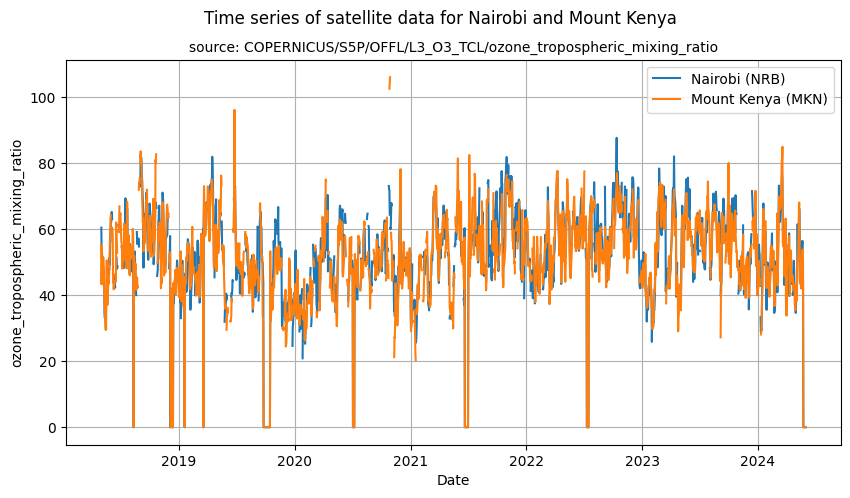

Retrieving and extracting variable 'ozone_tropospheric_mixing_ratio_precision' from collection 'COPERNICUS/S5P/OFFL/L3_O3_TCL' ...
Collection/variable: COPERNICUS/S5P/OFFL/L3_O3_TCL/ozone_tropospheric_mixing_ratio_precision


,dte,nrb,mkn
count,2224,1997.000000,2006.000000
mean,2021-05-15 12:00:00,4.702073,5.805851
min,2018-04-30 00:00:00,0.000000,0.000000
25%,2019-11-06 18:00:00,3.909120,4.080506
50%,2021-05-15 12:00:00,4.640395,5.604979
75%,2022-11-22 06:00:00,5.528919,7.369538
max,2024-05-31 00:00:00,13.249304,17.274401
std,NaN,1.667663,2.584869


<Figure size 640x480 with 0 Axes>

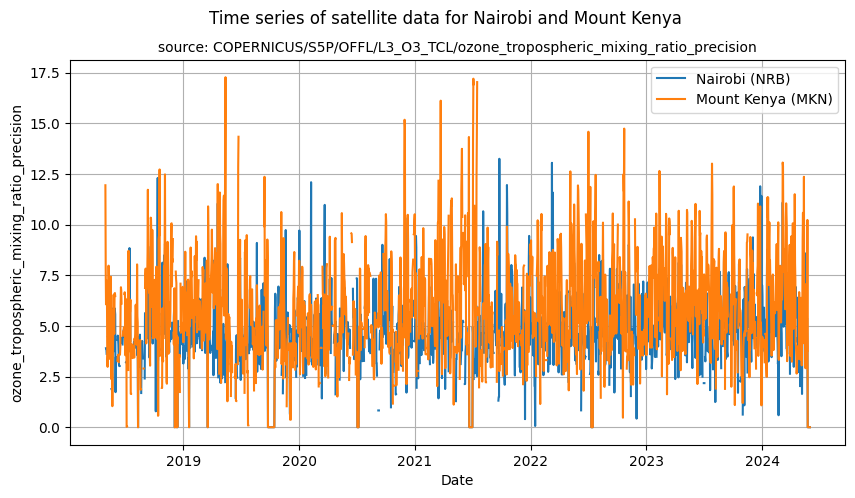

Retrieving and extracting variable 'ozone_tropospheric_vertical_column' from collection 'COPERNICUS/S5P/OFFL/L3_O3_TCL' ...
Collection/variable: COPERNICUS/S5P/OFFL/L3_O3_TCL/ozone_tropospheric_vertical_column


,dte,nrb,mkn
count,2224,2039.000000,2056.000000
mean,2021-05-15 12:00:00,0.010302,0.010519
min,2018-04-30 00:00:00,0.000000,0.000000
25%,2019-11-06 18:00:00,0.008988,0.009237
50%,2021-05-15 12:00:00,0.010408,0.010660
75%,2022-11-22 06:00:00,0.012180,0.012225
max,2024-05-31 00:00:00,0.017727,0.017448
std,NaN,0.002736,0.002739


<Figure size 640x480 with 0 Axes>

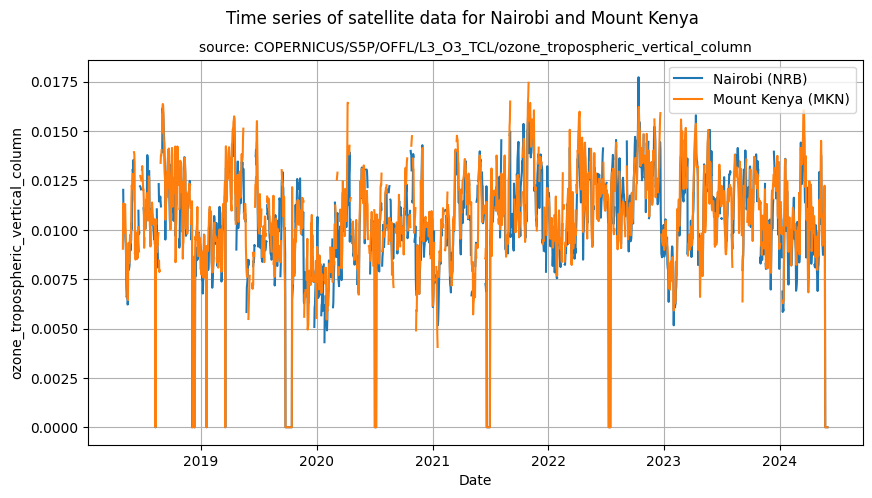

Retrieving and extracting variable 'ozone_tropospheric_vertical_column_precision' from collection 'COPERNICUS/S5P/OFFL/L3_O3_TCL' ...
Collection/variable: COPERNICUS/S5P/OFFL/L3_O3_TCL/ozone_tropospheric_vertical_column_precision


,dte,nrb,mkn
count,2224,1997.000000,2006.000000
mean,2021-05-15 12:00:00,0.000894,0.000941
min,2018-04-30 00:00:00,0.000000,0.000000
25%,2019-11-06 18:00:00,0.000738,0.000765
50%,2021-05-15 12:00:00,0.000875,0.000926
75%,2022-11-22 06:00:00,0.001062,0.001108
max,2024-05-31 00:00:00,0.002506,0.003117
std,NaN,0.000324,0.000361


<Figure size 640x480 with 0 Axes>

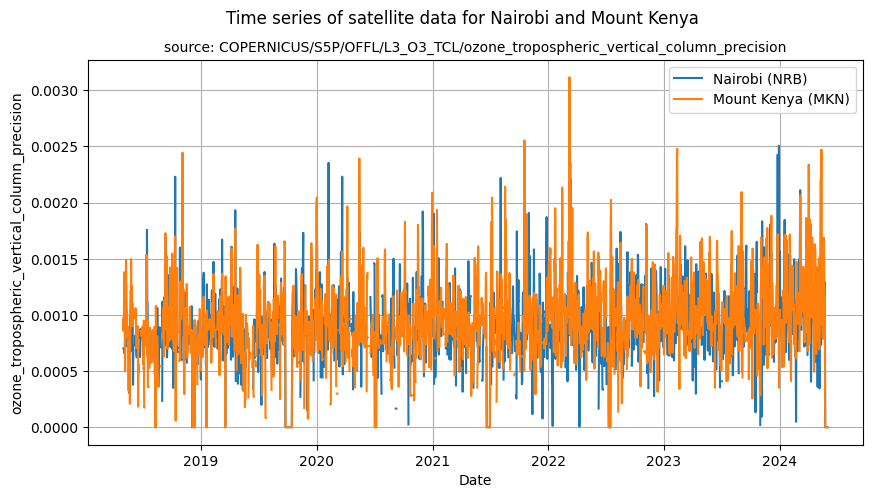

Retrieving and extracting variable 'qa_value' from collection 'COPERNICUS/S5P/OFFL/L3_O3_TCL' ...
Collection/variable: COPERNICUS/S5P/OFFL/L3_O3_TCL/qa_value


,dte,nrb,mkn
count,2224,2039.000000,2056.000000
mean,2021-05-15 12:00:00,87.469936,86.485409
min,2018-04-30 00:00:00,0.000000,0.000000
25%,2019-11-06 18:00:00,88.000000,87.000000
50%,2021-05-15 12:00:00,90.000000,89.000000
75%,2022-11-22 06:00:00,92.000000,91.000000
max,2024-05-31 00:00:00,95.000000,95.000000
std,NaN,15.046489,14.837908


<Figure size 640x480 with 0 Axes>

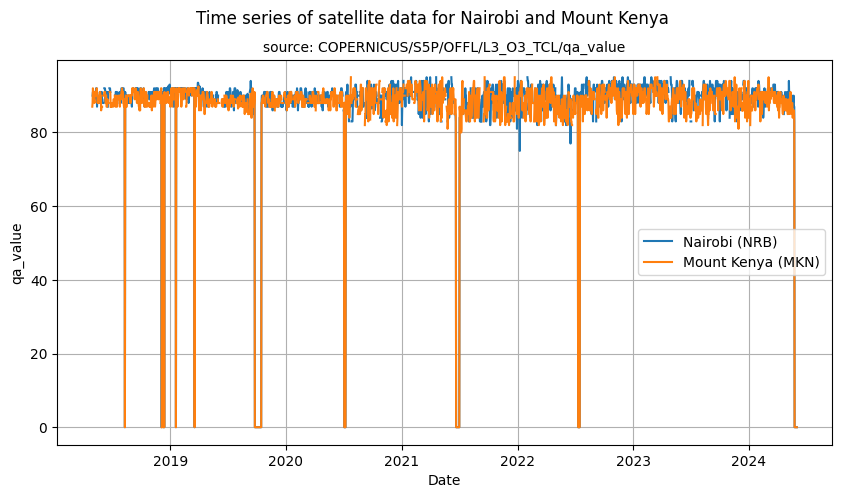

<Figure size 640x480 with 0 Axes>

In [3]:
# process specified collections
# collections_subset = ['COPERNICUS/S5P/NRTI/L3_O3_TCL','COPERNICUS/S5P/OFFL/L3_O3','COPERNICUS/S5P/OFFL/L3_O3_TCL']
collections_subset = ['COPERNICUS/S5P/OFFL/L3_O3_TCL']
for collection in collections.keys():
    if collection in collections_subset:
        for variable in collections[collection]['variables']:
            process_collection(collection=collection, variable=variable)

In [ ]:
# process all available collections
# NB: This will take several hours or even days to complete!
for collection in collections.keys():
    for variable in collections[collection]['variables']:
        process_collection()